# Ejemplo Random Forest - Clasificación de clientes de aseguradora

Estos datos son el resultado de las pólizas de una compañía aseguradora para el ramo 'Automotor - Moto'. Los datos están anonimizados y a su vez alterados para fines educativos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn import decomposition
from sklearn import tree
from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_excel('/content/drive/MyDrive/TUIA/Ejercicios/ejemplo_árboles/base_motos.xlsx')

## Análisis exploratorio

In [4]:
df.head()

,Siniestro,Marca,Cilindrada,Segmento,Edad,Antiguedad,Zona
0,0,GUERRERO,267,business,69,4,zonas_a
1,0,YAMAHA,401,calle,52,6,zonas_a
2,0,MONDIAL,428,enduro,39,3,zonas_a
3,0,HONDA,363,sport,73,5,zonas_a
4,1,GUERRERO,133,scooter,41,4,zonas_a


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Siniestro   2020 non-null   int64 
 1   Marca       2020 non-null   object
 2   Cilindrada  2020 non-null   int64 
 3   Segmento    2020 non-null   object
 4   Edad        2020 non-null   int64 
 5   Antiguedad  2020 non-null   int64 
 6   Zona        2020 non-null   object
dtypes: int64(4), object(3)
memory usage: 110.6+ KB


In [6]:
df.describe()

,Siniestro,Cilindrada,Edad,Antiguedad
count,2020.000000,2020.000000,2020.000000,2020.000000
mean,0.379208,348.503465,40.184653,3.899505
std,0.485310,145.738085,13.849759,2.567619
min,0.000000,90.000000,18.000000,0.000000
25%,0.000000,219.750000,29.000000,2.000000
50%,0.000000,357.500000,39.000000,4.000000
75%,1.000000,471.000000,50.000000,6.000000
max,1.000000,600.000000,75.000000,8.000000


Text(0.5, 1.0, 'Cantidad de siniestros por edad')

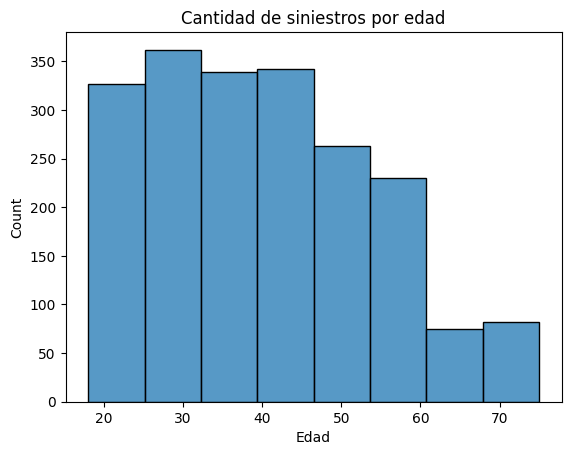

In [24]:
sns.histplot(x="Edad", bins=8, data=df)
plt.title('Cantidad de siniestros por edad')

Text(0.5, 1.0, 'Cantidad de siniestros por Cilindrada')

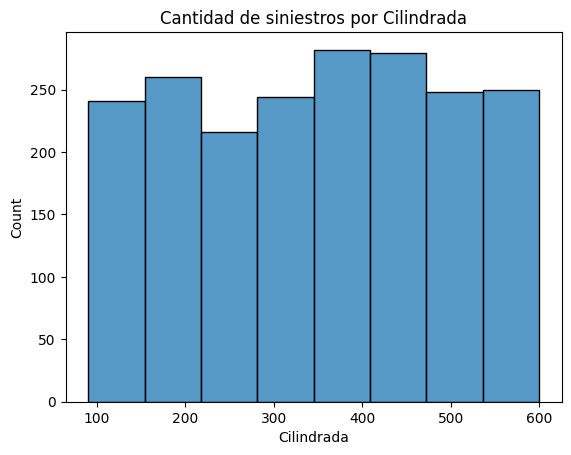

In [21]:
sns.histplot(x="Cilindrada", bins=8, data=df)
plt.title('Cantidad de siniestros por Cilindrada')

Text(0.5, 1.0, 'Cantidad de siniestros por antiguedad')

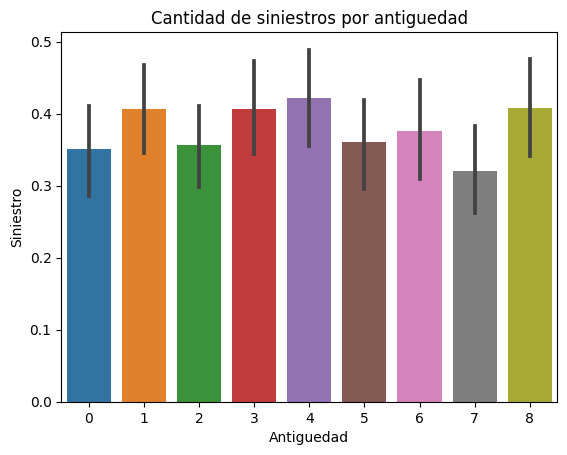

In [22]:
sns.barplot(x='Antiguedad', y='Siniestro', data=df)
plt.title('Cantidad de siniestros por antiguedad')

Text(0.5, 1.0, 'Cantidad de siniestros por zona')

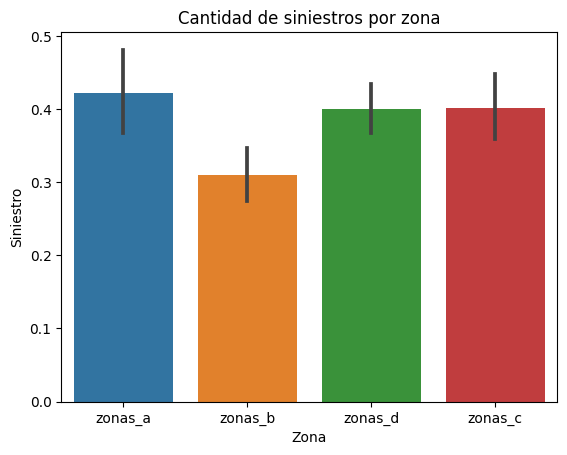

In [19]:
sns.barplot(x='Zona', y='Siniestro', data=df)
plt.title('Cantidad de siniestros por zona')

Text(0.5, 1.0, 'Cantidad de siniestros por Segmento')

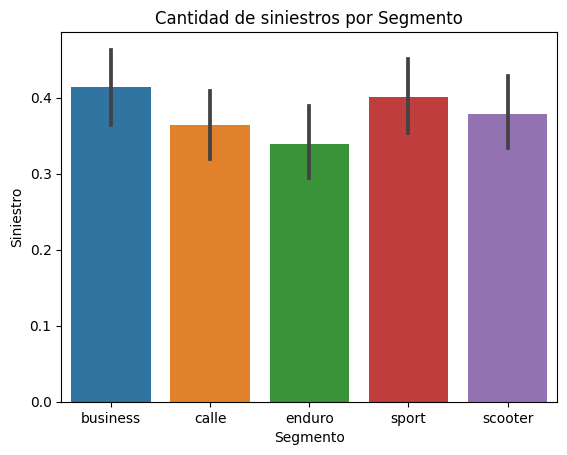

In [18]:
sns.barplot(x='Segmento', y='Siniestro', data=df)
plt.title('Cantidad de siniestros por Segmento')

Text(0.5, 1.0, 'Cantidad de siniestros por Marca')

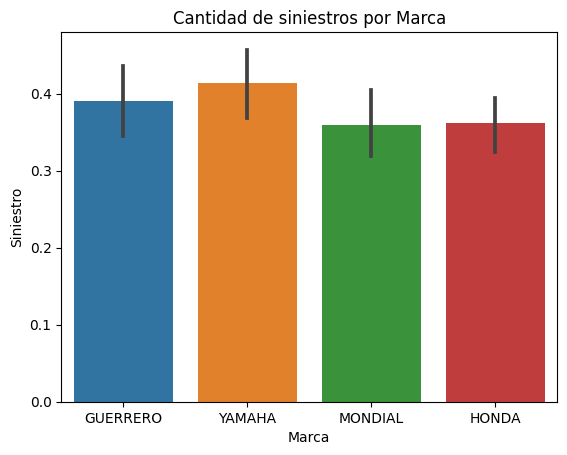

In [23]:
sns.barplot(x='Marca', y='Siniestro', data=df)
plt.title('Cantidad de siniestros por Marca')

## Random Forest

Generamos variables dummies

In [25]:
df_encoded = pd.get_dummies(df)

In [26]:
df_encoded.head()

,Siniestro,Cilindrada,Edad,Antiguedad,Marca_GUERRERO,Marca_HONDA,Marca_MONDIAL,Marca_YAMAHA,Segmento_business,Segmento_calle,Segmento_enduro,Segmento_scooter,Segmento_sport,Zona_zonas_a,Zona_zonas_b,Zona_zonas_c,Zona_zonas_d
0,0,267,69,4,1,0,0,0,1,0,0,0,0,1,0,0,0
1,0,401,52,6,0,0,0,1,0,1,0,0,0,1,0,0,0
2,0,428,39,3,0,0,1,0,0,0,1,0,0,1,0,0,0
3,0,363,73,5,0,1,0,0,0,0,0,0,1,1,0,0,0
4,1,133,41,4,1,0,0,0,0,0,0,1,0,1,0,0,0


### División train-test

In [27]:
df_train, df_test = train_test_split(df_encoded, test_size=0.3, random_state=1812)

In [28]:
# Definimos la variable objetivo (y)
train_labels = np.array(df_train['Siniestro'])
test_labels = np.array(df_test['Siniestro'])
# Quitamos la variable objetivo de nuestros dataframe de variables (x)
df_train = df_train.drop(['Siniestro'], axis = 1)
df_test = df_test.drop(['Siniestro'], axis = 1)
# Guardamos las variables que estamos usando
feature_list = list(df_train.columns)
# Convertimos los df de variables (x) a array
train_features = np.array(df_train)
test_features = np.array(df_test)

In [29]:
print(df_train.shape)
print(df_test.shape)
print(train_labels.shape)
print(test_labels.shape)

(1414, 16)
(606, 16)
(1414,)
(606,)


### Aplicación de la técnica

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=150,
                            max_depth=5,
                            max_features='sqrt',
                            random_state=2023
                            )

In [31]:
random_forest = rf.fit(train_features, train_labels)
predictions = rf.predict(test_features)

In [32]:
# features = feature_list
# classes = ['0', '1']

# for estimator in rf.estimators_:
#    print(estimator)
#    plt.figure(figsize=(20,6))
#    tree.plot_tree(estimator,
#                   feature_names=features,
#                   class_names=classes,
#                   fontsize=8,
#                   filled=True,
#                   rounded=True)
#    plt.show()

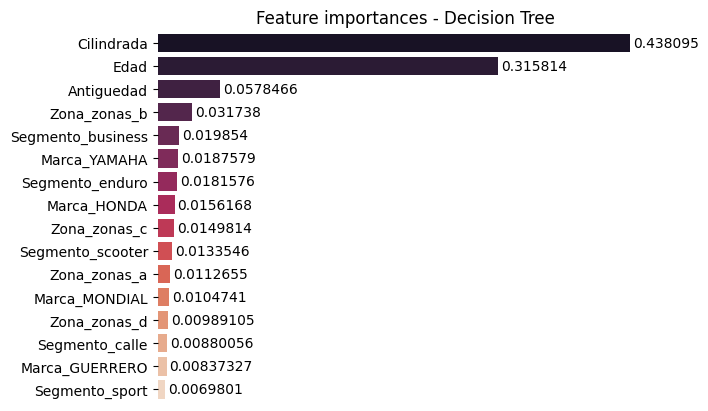

In [33]:
# Organizing feature names and importances in a DataFrame
features_df = pd.DataFrame({'features': feature_list, 'importances': random_forest.feature_importances_ })

# Sorting data from highest to lowest
features_df_sorted = features_df.sort_values(by='importances', ascending=False)

# Barplot of the result without borders and axis lines
g = sns.barplot(data=features_df_sorted, x='importances', y ='features', palette="rocket")
sns.despine(bottom = True, left = True)
g.set_title('Feature importances - Decision Tree')
g.set(xlabel=None)
g.set(ylabel=None)
g.set(xticks=[])
for value in g.containers:
    g.bar_label(value, padding=2)

### Métricas

In [35]:
from sklearn.metrics import classification_report

print(classification_report(test_labels, predictions, zero_division =0))

              precision    recall  f1-score   support

           0       0.72      0.84      0.78       385
           1       0.61      0.44      0.51       221

    accuracy                           0.69       606
   macro avg       0.67      0.64      0.64       606
weighted avg       0.68      0.69      0.68       606



### Optimización de hiperparámetros

In [34]:
from sklearn.model_selection import RandomizedSearchCV

max_features: Idealmente, el rendimiento global del modelo es el más alto cerca del valor 6 de las características máximas. Es una buena convención considerar el valor por defecto de este parámetro, que se establece en la raíz cuadrada del número de características presentes en el conjunto de datos. Por lo general, el número ideal de max_características tiende a situarse cerca de este valor.


https://www.analyticsvidhya.com/blog/2020/03/beginners-guide-random-forest-hyperparameter-tuning/

In [27]:
param_grid = {
    'n_estimators': [50, 150, 200, 500],
    'max_features': [3, 5, 6, 7, 9],
    'max_depth': [6, 9, 10, 11],
    'random_state': [18]
}
random_search = RandomizedSearchCV(RandomForestClassifier(),
                                   param_grid)
random_search.fit(train_features, train_labels)
first_best_params = random_search.best_params_
best_prediction = random_search.predict(test_features)
print(first_best_params)


{'random_state': 18, 'n_estimators': 200, 'max_features': 3, 'max_depth': 6}
